# Fase 1: O Alicerce (Regressão e Business Understanding)

#### Temos uma tabela com dados de pessoas como idade, sexto, IBM, número de filhos, se é fumante, região onde mora e quanto cada uma paga de seguro médico. 

#### Queremos prever quanto uma pessoa paga de seguro médico

## Passo 0 - Importando as bibliotecas que utilizaremos

In [1]:
import pandas as pd               # manipulação de tabelas (o "Excel do Python")
import numpy as np                # cálculos matemáticos/estatísticos
import matplotlib.pyplot as plt   # gráficos básicos
import seaborn as sns             # gráficos mais bonitos, construído em cima do matplotlib

## Passo 1 - Carregando os dados

In [2]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Passo 2 - Conhecendo os dados

In [3]:
df.info()        # tipos de coluna e se falta algum dado
df.describe()    # média, mínimo, máximo das colunas numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##### Vendo tudo que podemos fazer com esses dados:

In [4]:
df.head(10) # mostra as 10 primeiras (não só 5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
df.tail() # mostra as últimas linhas

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
df.sample(5)         # mostra 5 linhas aleatórias (bom pra não viciar só no início da tabela)

,age,sex,bmi,children,smoker,region,charges
512,51,male,22.420,0,no,northeast,9361.32680
128,32,female,17.765,2,yes,northwest,32734.18630
579,25,female,23.465,0,no,northeast,3206.49135
169,27,male,18.905,3,no,northeast,4827.90495
114,52,male,32.205,3,no,northeast,11488.31695


In [7]:
df.shape # (linhas, colunas) — ex: (1338, 7)

(1338, 7)

In [8]:
df.columns # lista os nomes das colunas

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## Passo 3 - Conhecendo os dados a fundo

In [9]:
df.info() 
# mostra quantas linhas cada coluna tem preenchida (para detectar dados faltantes) e o tipo de coluna que possui

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe() 
# mostra, só para colunas numéricas: contagem, média, desvio padrão, mínimo, quartis (25%/50%/75%), máximo.

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


##### Mais informações que podemos tirar desses dados

In [11]:
df.isnull().sum() # conta valores faltando por coluna (0 = sem problema)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.duplicated().sum() # conta linhas duplicadas

np.int64(1)

In [13]:
df = df.drop_duplicates()
df.shape   # confirma que caiu de 1338 para 1337 linhas

(1337, 7)

In [14]:
df['smoker'].unique() # valores únicos de uma coluna categórica

array(['yes', 'no'], dtype=object)

In [15]:
df['region'].value_counts() # conta quantas pessoas tem em cada região

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [46]:
df.describe()  # describe() das colunas de texto 

,age,bmi,children,charges,smoker_num
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487,0.204936
std,14.044333,6.100468,1.205571,12110.359656,0.403806
min,18.000000,15.960000,0.000000,1121.873900,0.000000
25%,27.000000,26.290000,0.000000,4746.344000,0.000000
50%,39.000000,30.400000,1.000000,9386.161300,0.000000
75%,51.000000,34.700000,2.000000,16657.717450,0.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000


Aqui conseguimos observar algumas informações legais:
* Idade média: 39 anos
* IMC médio: 30,6 (entrando dentro da faixa de obesidade de acordo com a OMS)
* Valor do seguro com média de 13270 mas o desvio padrão é de 12110 (a distribuição é bem espalhada/assimétrica)

In [17]:
df.dtypes # tipo de cada coluna, isolado

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

#### O que queremos observar aqui?
* Se falta algum dado
* Se tem linha duplicada 
* Se os valores fazem sentido

## Passo 4 - Análise exploratória visual (EDA)

Vamos analisar mais a fundo o que esses dados estão nos dizendo :D

### 4.1 Distribuição de cada variável numérica

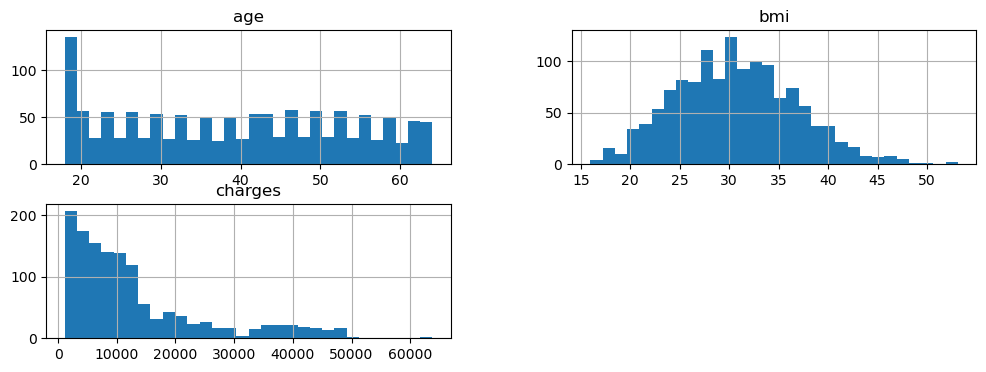

In [47]:
df[['age','bmi','charges']].hist(bins=30, figsize=(12,4))
plt.title ("Histogramas")
plt.show()

Reparamos aqui que "charges" costuma ter uma cauda longa à direita (poucas pessoas pagam muito caro)
Isso se chama distribuição assimétrica (skewed).

### 4.2 Como charges varia por categoria

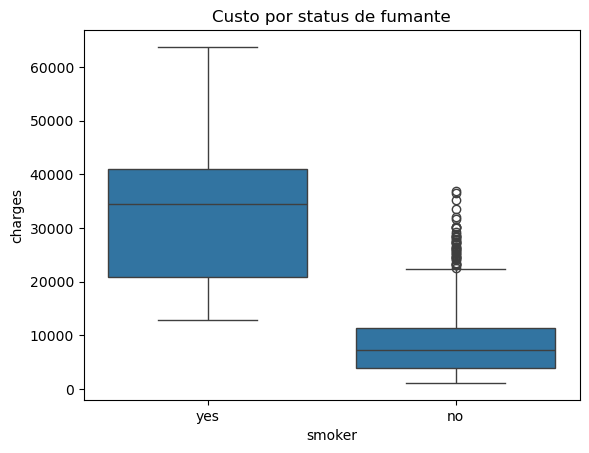

In [19]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Custo por status de fumante')
plt.show()

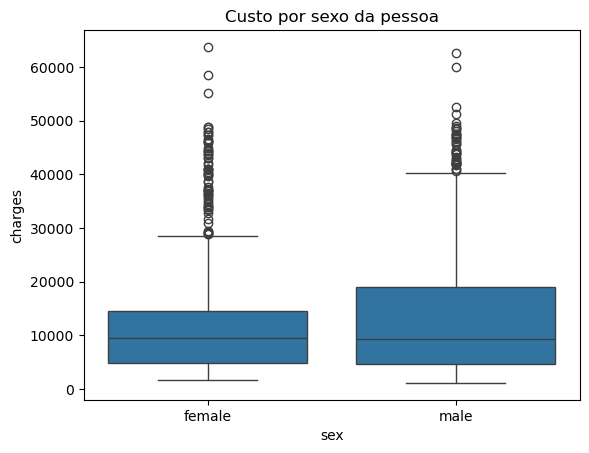

In [20]:
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Custo por sexo da pessoa')
plt.show()

Vendo esses dois boxplots acima, conseguimos verificar E validar que a variável FUMAR está associada a 4x mais custo, sendo a variável dominante do dataset. Qualquer modelo que ignore essa informação vai ser incorreto ou defasado.

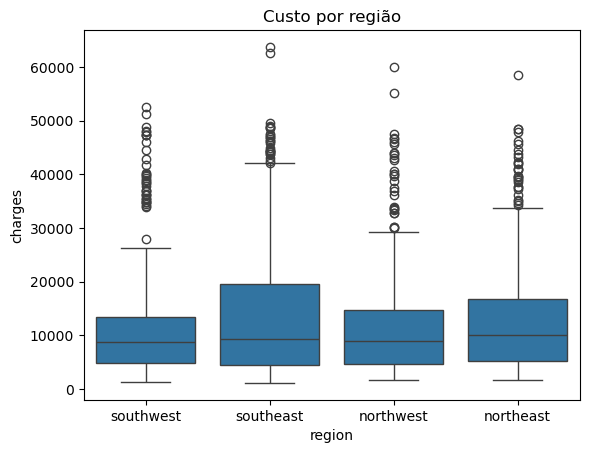

In [21]:
sns.boxplot(x='region', y='charges', data=df)
plt.title('Custo por região')
plt.show()

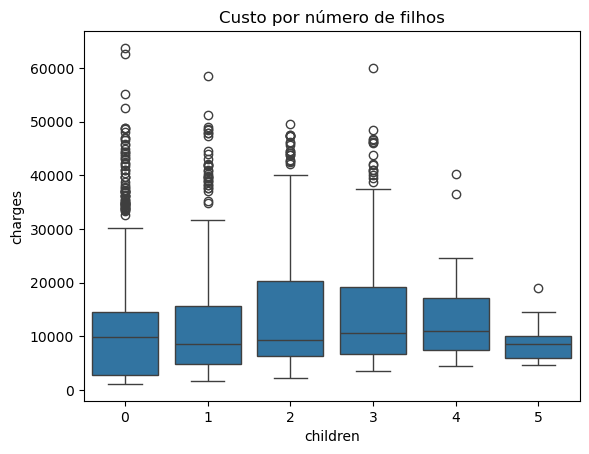

In [22]:
sns.boxplot(x='children', y='charges', data=df)
plt.title('Custo por número de filhos')
plt.show()

Precisamos observar se caixas (médias) são bem diferentes entre categorias
Essa variável provavelmente importa para o modelo.

### 4.3 Scatter plot: relação entre duas variáveis numéricas

<Axes: xlabel='bmi', ylabel='charges'>

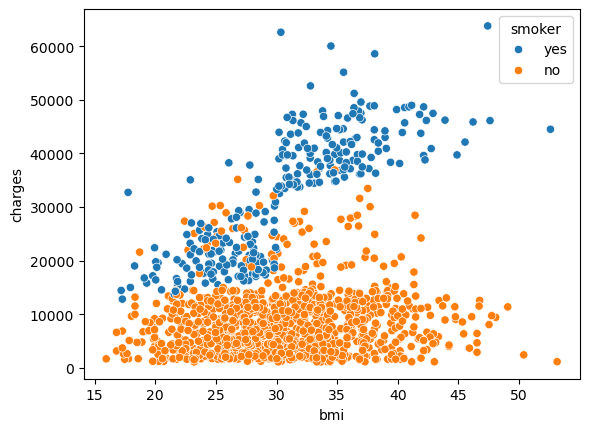

In [23]:
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
# o hue='smoker' colore os pontos por fumante/não fumante

<Axes: xlabel='age', ylabel='charges'>

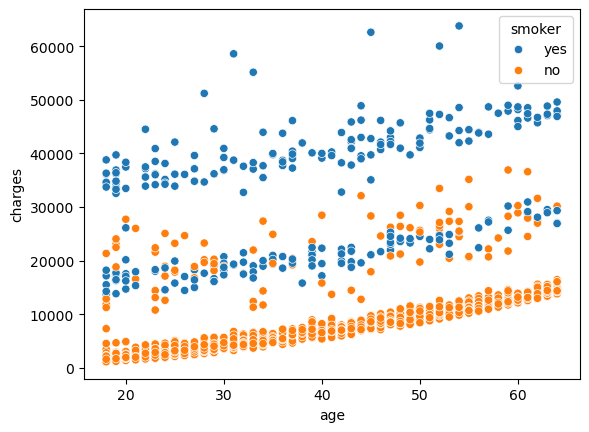

In [24]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)

Aqui conseguimos ver visualmente a interação entre fumantes X IMC

Entre fumantes, o IMC parece ter um efeito muito mais forte no custo do que entre não-fumantes (os pontos fumantes com IMC alto disparam pra cima). Isso é a pista visual de que existe uma interação smoker × bmi, que a regressão linear simples não captura sozinha (ela assume que cada variável soma seu efeito de forma independente).

### 4.4 Pairplot — visão geral de tudo de uma vez

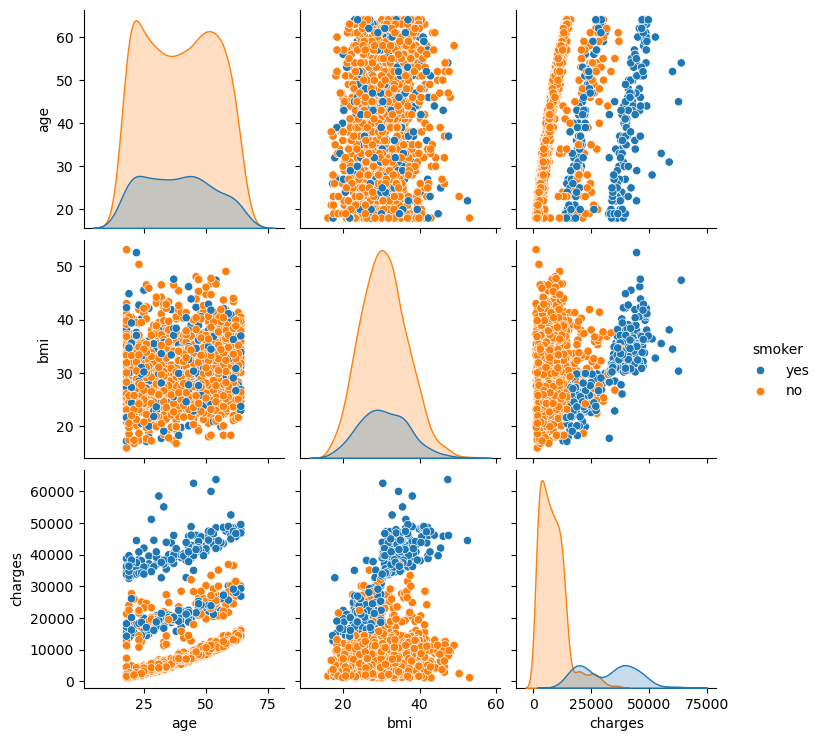

In [25]:
sns.pairplot(df, hue='smoker', vars=['age','bmi','charges'])

Mostra todos os scatter plots cruzados de uma vez. 
Muito bom pra ter visão geral rápida.

### 4.5 Agrupamentos com groupby

In [26]:
df.groupby('smoker')['charges'].mean()          # custo médio por fumante/não
df.groupby('region')['charges'].mean()          # custo médio por região
df.groupby(['smoker','sex'])['charges'].mean()  # cruzando duas categorias

smoker  sex   
no      female     8762.297300
        male       8099.700161
yes     female    30678.996276
        male      33042.005975
Name: charges, dtype: float64

## Passo 5 - Correlação

A correlação é verificar se quando uma variável muda, outra muda junto.
Varia de -1 a +1

In [27]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


Interpretação: essas três correlações são fracas a moderadas. Isoladas, nenhuma delas prevê charges muito bem.

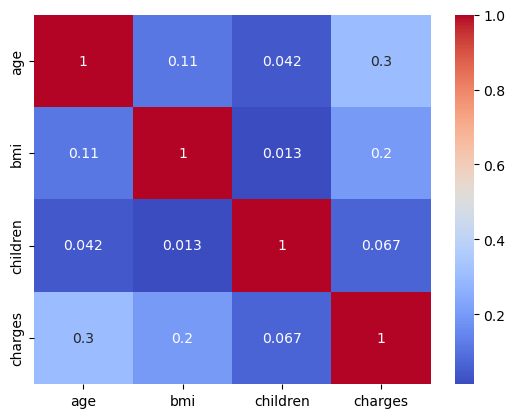

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [29]:
df.corr(numeric_only=True, method='pearson')   # padrão — mede relação LINEAR

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [30]:
df.corr(numeric_only=True, method='spearman')  # mede relação monótona (não precisa ser linear)

,age,bmi,children,charges
age,1.000000,0.107897,0.055813,0.533523
bmi,0.107897,1.000000,0.015643,0.119585
children,0.055813,0.015643,1.000000,0.132200
charges,0.533523,0.119585,0.132200,1.000000


In [31]:
df[['age','charges']].corr() # correlação entre só duas colunas específicas

,age,charges
age,1.000000,0.298308
charges,0.298308,1.000000


Limitação importante: df.corr() só funciona com números. smoker, sex, region (texto) ficam de fora

Para ver se uma variável categórica importa, use os boxplots do Passo 4.2 ou converta a variável para 0/1 primeiro:

In [32]:
df['smoker_num'] = df['smoker'].map({'yes':1, 'no':0})
df[['smoker_num','charges']].corr()

,smoker_num,charges
smoker_num,1.000000,0.787234
charges,0.787234,1.000000


Mas ao converter smoker para uma função numérica para verificar a correlação, temos uma correlação forte.

Correlação forte ≠ a variável mais importante sempre

correlação fraca ≠ variável inútil.

A idade tem correlação fraca com charges sozinha, mas ainda apareceu como estatisticamente significativa no modelo final.

#### P-valor da correlação (mostra se a correlação é estatisticamente significativa ou pode ser coincidência):

In [33]:
from scipy.stats import pearsonr
corr, p_valor = pearsonr(df['age'], df['charges'])
print(f'Correlação: {corr:.3f}, p-valor: {p_valor:.5f}')

Correlação: 0.298, p-valor: 0.00000


Se p-valor < 0.05 → a correlação é "real", não coincidência.

## Passo 6 - Preparando os dados

### Opção A: One-Hot Encoding (a mais usada com regressão)

In [34]:
df_encoded = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)
df_encoded.head()

,age,bmi,children,charges,smoker_num,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,False,True,False,False,True
1,18,33.770,1,1725.55230,0,True,False,False,True,False
2,28,33.000,3,4449.46200,0,True,False,False,True,False
3,33,22.705,0,21984.47061,0,True,False,True,False,False
4,32,28.880,0,3866.85520,0,True,False,True,False,False


`drop_first=True` evita redundância (se não é "yes", já sabemos que é "no", não precisa das duas colunas).

O que aconteceu: `smoker` virou `smoker_yes` (1 ou 0). `region` (4 categorias) virou 3 colunas tipo `region_northwest`, `region_southeast`, `region_southwest`.

## Passo 7: Separar X (pistas) e y (resposta)

In [35]:
X = df_encoded.drop(['charges', 'smoker_num'], axis=1)
y = df_encoded['charges']

## Passo 8: Separar treino e teste

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Por que fazemos isso? 

Testar o modelo com os mesmos dados que ele "estudou" seria como dar a prova pro aluno estudar e fazer a prova com a folha de respostas na mão. Separamos uma fatia (aqui, 20%) que o modelo nunca viu, para testar de verdade.

Parâmetros
* test_size=0.3 → separa 30% para teste em vez de 20% (comum usar entre 0.2 e 0.3)
* random_state=42 → "trava" o sorteio aleatório, pra você conseguir reproduzir o mesmo resultado depois. Pode ser qualquer número, 42 é só convenção da comunidade
* shuffle=True (padrão) → embaralha antes de separar, evitando pegar só um pedaço "enviesado" da tabela

## Passo 9 - Treinar o modelo

Com scikit-learn (mais direto ao ponto)

In [37]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Com statsmodels (dá muito mais detalhe estatístico)

In [38]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)   # adiciona o "intercepto" manualmente
modelo_sm = sm.OLS(y_train, X_train_sm.astype(float)).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Tue, 28 Jul 2026   Prob (F-statistic):          4.94e-295
Time:                        11:58:26   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.109e+04   1114.260  

O `summary()` do statsmodels te dá de graça: coeficientes, p-valor de cada variável, R², intervalo de confiança. É o jeito "acadêmico" de rodar regressão, muito usado quando o objetivo é interpretar, não só prever.

## Passo 10: Interpretar os coeficientes

Interpretando as informações acima:
* age = 248,21 → mantendo tudo mais constante, cada ano a mais de idade soma 248 reais no custo previsto
* bmi = 318,70 → cada ponto a mais de IMC soma 319 reais 
* children = 533,01 → cada filho a mais soma 533 reais 
* sex_male = -101,54 → ser homem (vs. mulher, que é a categoria de referência por causa do drop_first) reduz o custo previsto em 102 reais  — efeito pequeno, quase irrelevante
* smoker_yes = 23.077,76 → ser fumante soma 23.077 ao custo previsto. É de longe o coeficiente com maior peso — confirma tudo que você já tinha visto no boxplot e na correlação
* region_southeast = -838,92 → morar no sudeste (vs. nordeste, categoria de referência) reduz o custo previsto em 839
* Intercepto = -11.092,65 → é o valor "base" quando todas as variáveis são zero (mulher, não-fumante, 0 filhos, idade 0, IMC 0, região nordeste). Sozinho não tem interpretação prática (ninguém tem idade 0), ele só ajusta a equação matematicamente

In [39]:
coeficientes = pd.DataFrame({
    'variavel': X_train.columns,
    'coeficiente': modelo.coef_
})
print(coeficientes)
print('Intercepto:', modelo.intercept_)

           variavel   coeficiente
0               age    248.210720
1               bmi    318.701441
2          children    533.009989
3          sex_male   -101.542054
4        smoker_yes  23077.764593
5  region_northwest   -391.761455
6  region_southeast   -838.919616
7  region_southwest   -659.139752
Intercepto: -11092.652295945947


Se o coeficiente de age for 257, significa: "mantendo todas as outras variáveis constantes, cada ano a mais de idade aumenta o custo previsto em ~257 (na moeda do dataset)".

Se estiver usando statsmodels, olhe a coluna P>|t| no summary() — variáveis com p-valor < 0.05 são estatisticamente significativas (têm efeito "real", não é ruído).

## Passo 11 - Fazer previsões

In [40]:
y_pred = modelo.predict(X_test)

Comparando lado a lado:

In [41]:
comparacao = pd.DataFrame({'real': y_test, 'previsto': y_pred})
comparacao.head(10)

,real,previsto
900,8688.85885,8143.693884
1064,5708.86700,5737.115683
1256,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657
481,9304.70190,13149.722353
240,38511.62830,30446.760679
277,2150.46900,1453.288813
415,7345.72660,10633.018402
707,10264.44210,11318.943794


## Passo 12 - Avaliar o modelo

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

MAE: 4177.05
MSE: 35478020.68
RMSE: 5956.34
R²: 0.8069


Interpretação:
* MAE de 4.177: em média, o modelo erra 4.177 pra mais ou pra menos
* RMSE de 5.956 (maior que o MAE, como sempre acontece): confirma que existem alguns erros grandes puxando a média pra cima — coerente com aquela cauda longa que você viu no histograma
* R² de 0,8069: o modelo explica ~80,7% da variação nos custos. É um resultado bom pra regressão linear simples nesse tipo de dado

O que cada métrica significa:
* MAE (erro absoluto médio): em média, o quanto o modelo erra, na mesma unidade do dado (fácil de explicar pra não-técnico: "erra em média R$X")
* MSE: parecido, mas eleva os erros ao quadrado antes de tirar a média — pune mais os erros grandes
* RMSE: raiz quadrada do MSE — volta pra unidade original (mais interpretável que MSE puro)
* R²: de 0 a 1 (às vezes pode ser negativo se o modelo for muito ruim) — "porcentagem da variação dos dados que o modelo consegue explicar". R² = 0.75 → modelo explica 75% do porquê os custos variam

## Passo 13 - Diagnóstico de resíduos

Resíduo = diferença entre o valor real e o previsto (y_test - y_pred). Analisar os resíduos mostra se o modelo linear está bem ajustado ou se está "cegando" para algum padrão.

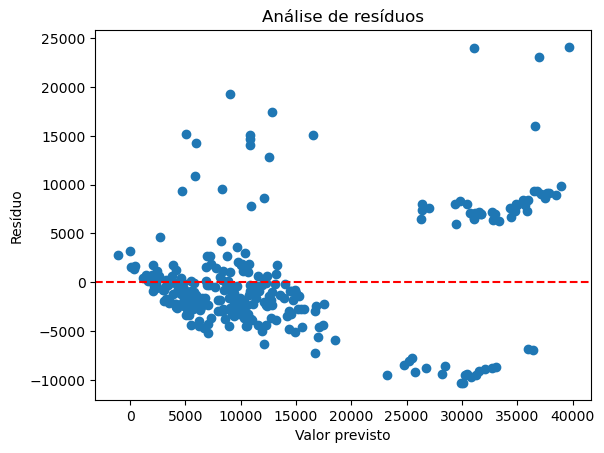

In [43]:
residuos = y_test - y_pred

# Gráfico 1: Previsto vs Resíduo
plt.scatter(y_pred, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valor previsto')
plt.ylabel('Resíduo')
plt.title('Análise de resíduos')
plt.show()

Temos claramente 3 grupos/nuvens separadas, não uma nuvem só:
* Grupo grande à esquerda (previsto de 0 a ~18.000): uma nuvem densa que forma um leve "V" ou curva — começa positiva perto do zero, desce, e depois sobe de novo nos valores mais altos desse grupo
* Grupo do meio (previsto ~23.000 a ~30.000): uma faixa isolada, quase toda com resíduo negativo (entre -5.000 e -10.000)
* Grupo da direita (previsto ~30.000 a ~40.000): outra faixa isolada, com resíduos bem variados, incluindo os maiores erros positivos do gráfico (+20.000 a +24.000)

Por que isso acontece?

Isso não é aleatório: é a assinatura de uma variável categórica escondida que o modelo linear não representa como "grupos" separados. Nesse dataset específico, o padrão é bem conhecido:

Grupo 1 = não-fumantes (a maioria dos dados, custo mais baixo e mais previsível)
Grupos 2 e 3 = fumantes — mas divididos entre fumantes com IMC mais baixo vs fumantes com IMC ≥ ~30 (obesidade)

Fumantes obesos têm um custo que dispara de forma quase multiplicativa, não apenas soma um valor fixo — é um salto muito mais agressivo do que a regressão linear consegue representar somando smoker_yes (23.077) + bmi × 318 separadamente. O modelo está tratando esse efeito como aditivo, quando na realidade ele é interativo (o efeito do IMC muda dependendo de você ser fumante ou não).

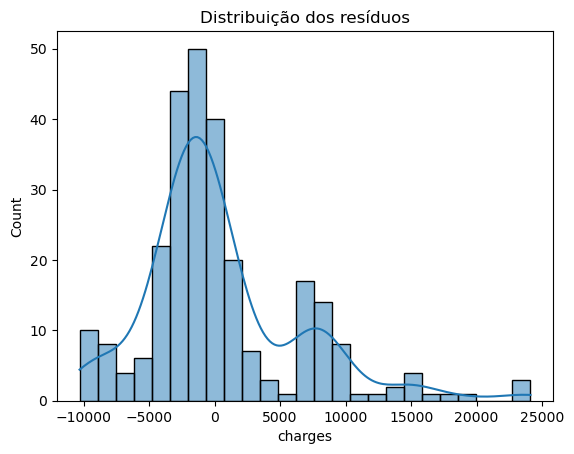

In [44]:
# Gráfico 2: os resíduos seguem distribuição normal? (pressuposto da regressão linear)
sns.histplot(residuos, kde=True)
plt.title('Distribuição dos resíduos')
plt.show()

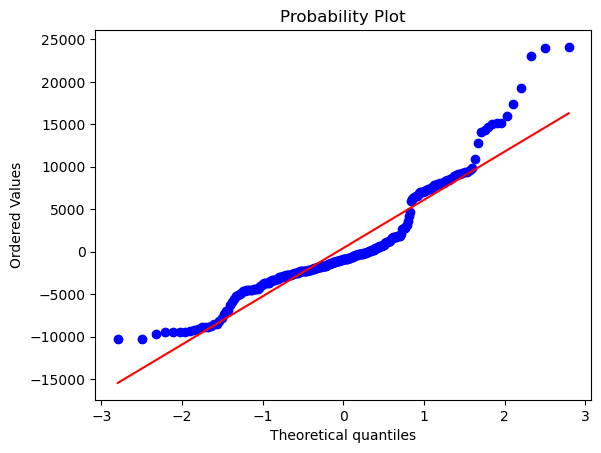

In [45]:
# Gráfico 3: QQ-plot (compara resíduos com uma normal teórica)
import scipy.stats as stats
stats.probplot(residuos, dist="norm", plot=plt)
plt.show()